In [49]:
# Imports
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import WCSAxes
from astropy.coordinates import SkyCoord, FK5
from spectral_cube import SpectralCube
from velocity_tools import extract_streamline, gradient_descent, stream_lines_grad
from velocity_tools import stream_lines # won't use this directly, but needed to compare with stream_lines_grad
import os

import warnings
warnings.filterwarnings('ignore', message='.*PV2_1.*')
warnings.filterwarnings('ignore', message='.*PV2_2.*')
warnings.filterwarnings('ignore', message='.*TIMESYS.*')

# Settings
hltau_c= SkyCoord("4h31m38.43s", "+18d13m57.19s", frame='fk5')
hltau_ref = hltau_c.skyoffset_frame()
distance = 147 #parsecs
cubefile = 'test_data/HLTAU_HCOp32.fits'
file_TdV = 'test_data/HLTAU_HCOp32_TdV.fits'


### TODO: Extract streamer cube from original cube
### Prepare the 1D streamer emission from the cube

In [50]:
# get the spectralcube object from the data using spectral-cube
hdu = fits.open(cubefile)[0]
cube = SpectralCube.read(hdu).with_spectral_unit(u.km/u.s, rest_value=hdu.header['RESTFRQ']*u.Hz)

# if the mom0 map isn't made yet, make it
if not os.path.exists(file_TdV):
    cube_mom0 = cube.moment0()
    hdu_mom0 = cube_mom0.hdu
    hdu_mom0.writeto(file_TdV)
print("Loaded cube with shape:", cube.shape)

# TODO: this streamer extraction should be replaced with clustering-based streamer extraction

# extract the subcube with the streamer (we got this from the tipsy tutorial, no need to plot)
## Limits for extracting subcube with streamer
vmin = 7    # Min. vel. of streamer
vmax = 10
xmin = -3   # Min R.A. offset to consider for streamer
xmax = -1
ymin = -3   # Min. Decl. offset to consider for stremar
ymax = 0.5
rms_thresh = 4  # sigma threshold for streamer

# extract the streamer subcube
info_header = cube.header  # header of the cube, contains required information
x_conv_fac = 1/60/60/info_header['CDELT1']
xmin_p = int((xmin*x_conv_fac)+info_header['CRPIX1'])
xmax_p = int((xmax*x_conv_fac)+info_header['CRPIX1'])
y_conv_fac = 1/60/60/info_header['CDELT2']
ymin_p = int((ymin*y_conv_fac)+info_header['CRPIX2'])
ymax_p = int((ymax*y_conv_fac)+info_header['CRPIX2'])
vunit = cube.spectral_axis.unit
## Note: a check can be added to see if requested limits are within the limits of the cube itself

streamer_cubev = cube.spectral_slab(vmin*vunit,vmax*vunit)    # Selecting velocities
streamer_cubevc = streamer_cubev[:,min(ymin_p,ymax_p):max(ymin_p,ymax_p)   
                    ,min(xmin_p,xmax_p):max(xmin_p,xmax_p)]   # Selecting pixels
#     print(min(ymin_p,ymax_p),max(ymin_p,ymax_p),min(xmin_p,xmax_p),max(xmin_p,xmax_p)) 
streamer_cube = streamer_cubevc.with_mask(streamer_cubevc > rms_thresh*streamer_cubevc.mad_std())  # Removing low flux values 


Loaded cube with shape: (500, 401, 401)


In [51]:

# Extract 1D streamline from the data cube
pc_coords, pc_means, pc_stds = extract_streamline.reduce_to_1D(streamer_cube, n_elements=10)

Starting reduction
Created coordinate arrays
Got point cloud with 14974 points
Partition boundaries for projected distance metric: [1.031 1.122 1.176 1.234 1.3   1.383 1.48  1.602 1.732 1.898 3.251]


Text(0.5, 1.0, 'Extracted 1D Streamer emission')

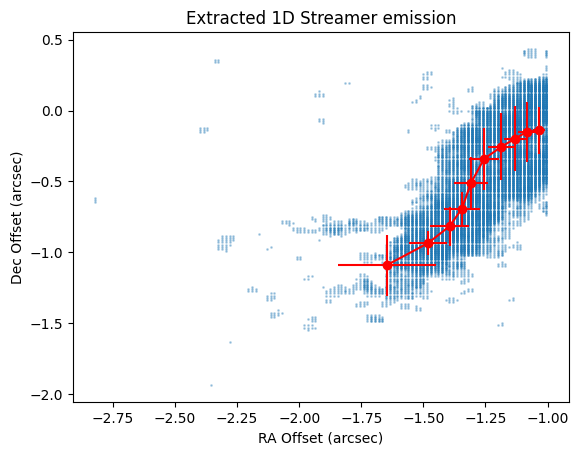

In [52]:
# plot it
import matplotlib.pyplot as plt
# plot the observed data points as a scatter
plt.scatter(pc_coords[0], pc_coords[1], s=1, alpha=0.3, label='Point cloud')
# plot the extracted 1D streamline with error bars
plt.errorbar(pc_means[0], pc_means[1], xerr=pc_stds[0], yerr=pc_stds[1], fmt='o-', label='Extracted 1D Streamline', color='red')
plt.xlabel('RA Offset (arcsec)')
plt.ylabel('Dec Offset (arcsec)')
plt.title('Extracted 1D Streamer emission')

### Initial guess at parameters, and plot

This plot shows that stream_lines_grad is not working well and has some kind of instability.

rc=1.9220526946751497 AU
5.0 AU
tolerance  1.7951744484000003e-07


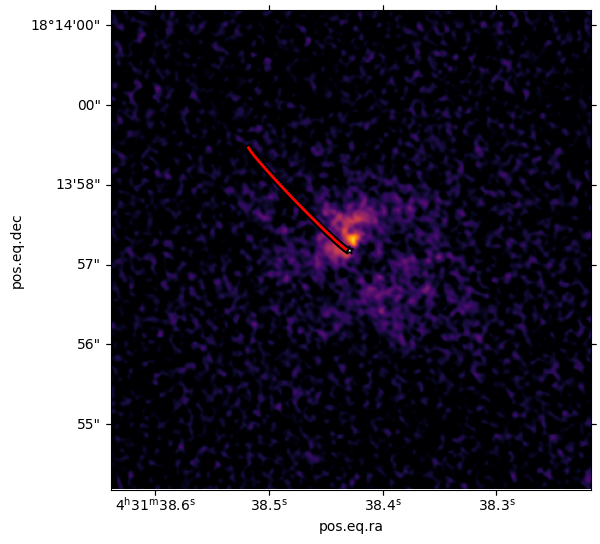

In [ ]:
# Initial guesses at params
theta0 = 130.*u.deg
r0 = 1000*u.au
phi0 = 70.*u.deg
v_r0 = 0*u.km/u.s
omega0 = 4e-13/u.s
v_lsr = 7.14*u.km/u.s
inc = -43*u.deg
PA_ang = 130*u.deg
Mstar = 2.1*u.Msun

# Run the forward model with initial params
# x = RA offset (au), y = velocity (km/s), z = Dec offset (au)
(x1, y1, z1), (vx1, vy1, vz1) = stream_lines_grad.xyz_stream(
                mass=Mstar, r0=r0, theta0=theta0, phi0=phi0,
                omega=omega0, v_r0=v_r0, inc=inc, pa=PA_ang,
                rmin=0.5e2*u.au, deltar=5*u.au) #<- decrease deltar for more accurate streamer calculation
dra_stream = -x1._value / distance * u.arcsec # note the _value to get raw number for stream_lines_grad
ddec_stream = z1._value / distance * u.arcsec
fil = SkyCoord(dra_stream, ddec_stream, frame=hltau_ref).transform_to(FK5)
# Load the moment 0 data
hdu = fits.open(file_TdV)[0]
wcs_TdV = WCS(hdu.header)
# create figure
plt.close('all')
fig = plt.figure(1, figsize=(6, 6))
ax = WCSAxes(fig, [0.1, 0.1, 0.8, 0.8], wcs=wcs_TdV.celestial)
fig.add_axes(ax)  # note that the axes have to be explicitly added to the figure
im = ax.imshow(hdu.data, cmap='inferno',
               vmin=0, vmax=160.e-3)#, transform=ax.get_transform(wcs_TdV))
ax.scatter(hltau_c.ra, hltau_c.dec, marker='*', transform=ax.get_transform('world'),
    facecolor='white', edgecolor='black')
ax.plot(fil.ra, fil.dec,  color='black', transform=ax.get_transform('world'), linewidth=5)
ax.plot(fil.ra, fil.dec,  color='red', transform=ax.get_transform('world'), linewidth=2)
plt.show()